In [1]:
import sys

from sklearn.model_selection import train_test_split

sys.path.append('../../../Share')
import config, baseline, Target, Model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

In [3]:
SUBJECT = "Hunmin"
baseline_K_val = [i for i in range(len(config.dataset_sub_H))]


ACC_lst = []
for i, K in enumerate([1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    #X_train, y_train = balance_data(X_train, y_train)
    X_test, y_test, _, _ = trainer.return_K_th_data_only(65, train_ratio=1)
    #X_test, y_test = balance_data(X_test, y_test)
    #model = Model.Original_model(X_train.shape[1:], num_class=6)
    model = Model.Original_model2(X_train.shape[1:], num_class=6)
    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print('acc:', acc)

Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Returning K-th session data: Exp_2025-08-01-v3/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
acc: 0.8871360421180725


In [ ]:
#acc: 0.4476987421512604

In [7]:
import tensorflow as tf
from tensorflow.keras import callbacks
from tensorflow.keras.callbacks import ModelCheckpoint

ACC_lst = []

for i, K in enumerate([31]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=0.2)
    #X_train, y_train = balance_data(X_train, y_train)
    X_test, y_test, _, _ = trainer.return_K_th_data_only(65, train_ratio=1)
    #X_test, y_test = balance_data(X_test, y_test)

    # Build model

    model2 = Model.Original_model(X_train.shape[1:], num_class=6)

    # Compile model with Adam optimizer (fixed initial lr)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model2.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Custom learning rate schedule: halve lr every 3 epochs (except epoch 0)
    lr_schedule = callbacks.LearningRateScheduler(
        lambda epoch, lr: lr * 0.5 if epoch % 3 == 0 and epoch != 0 else lr
    )

    # Save best model based on validation accuracy
    checkpoint_path = f"best_model_subject_{SUBJECT}_K50_m2_unbalanced.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=0
    )

    history = model2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=150, batch_size=256, callbacks=[lr_schedule, checkpoint],shuffle=True, verbose=0)
    best_model = tf.keras.models.load_model(checkpoint_path)
    test_acc = best_model.evaluate(X_test, y_test, verbose=0)[1]
    print("Validation-best test accuracies:", test_acc, f"   {np.max(history.history['val_accuracy']):.2f}")

    #Validation-best test accuracies: 0.84030681848526
    # 8026499152183533 - 50

Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Dataset 2/66 - Session Exp_2025-06-18/E9AD0E7DCC2B/
Dataset 3/66 - Session Exp_2025-06-20-v1/E9AD0E7DCC2B/
Dataset 4/66 - Session Exp_2025-06-20-v2/E9AD0E7DCC2B/
Dataset 5/66 - Session Exp_2025-06-20-v3/E9AD0E7DCC2B/
Dataset 6/66 - Session Exp_2025-06-20-v4/E9AD0E7DCC2B/
Dataset 7/66 - Session Exp_2025-06-20-v5/E9AD0E7DCC2B/
Dataset 8/66 - Session Exp_2025-06-20-v6/E9AD0E7DCC2B/
Dataset 9/66 - Session Exp_2025-06-20-v7/E9AD0E7DCC2B/
Dataset 10/66 - Session Exp_2025-06-20-v8/E9AD0E7DCC2B/
Dataset 11/66 - Session Exp_2025-06-23-v1/E9AD0E7DCC2B/
Dataset 12/66 - Session Exp_2025-06-23-v2/E9AD0E7DCC2B/
Dataset 13/66 - Session Exp_2025-06-23-v3/E9AD0E7DCC2B/
Dataset 14/66 - Session Exp_2025-06-23-v4/E9AD0E7DCC2B/
Dataset 15/66 - Session Exp_2025-06-24-v1/E9AD0E7DCC2B/
Dataset 16/66 - Session Exp_2025-06-24-v2/E9AD0E7DCC2B/
Dataset 17/66 - Session Exp_2025-06-24-v3/E9AD0E7DCC2B/
Dataset 18/66 - Session Exp_2025-06-24-v4/E9AD0E7DCC2B/
Dataset

Validation-best test accuracies: 0.9250667095184326    0.93


In [8]:
from sklearn.model_selection import train_test_split

for i, K in enumerate([64]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=0.2)
    #X_train, y_train = balance_data(X_train, y_train)
    X_test, y_test, _, _ = trainer.return_K_th_data_only(65, train_ratio=1)
    #X_test, y_test = balance_data(X_test, y_test)

    model2 = Model.Original_model(X_train.shape[1:], num_class=6)

    # Compile model with Adam optimizer (fixed initial lr)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model2.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Custom learning rate schedule: halve lr every 3 epochs (except epoch 0)
    #lr_schedule = callbacks.LearningRateScheduler(lambda epoch, lr: lr * 0.5 if epoch % 3 == 0 and epoch != 0 else lr)
    X_train2, X_test2, y_train2, y_test2 = train_test_split(X_test, y_test, test_size=0.2, random_state=42)

    X_train = np.concatenate([X_train, X_train2], axis=0)
    y_train = np.concatenate([y_train, y_train2], axis=0)

    callbacks = [lr_schedule, checkpoint]
    # Save best model based on validation accuracy
    checkpoint_path = f"best_model_subject_{SUBJECT}_K64_good_unbalanced.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=0
    )

    history = model2.fit(X_train, y_train, validation_data=(X_test2, y_test2), epochs=150, batch_size=256, callbacks=[checkpoint],shuffle=True, verbose=0)
    best_model = tf.keras.models.load_model(checkpoint_path)
    test_acc = best_model.evaluate(X_test, y_test, verbose=0)[1]
    print("Validation-best test accuracies:", test_acc, f"   {np.max(history.history['val_accuracy']):.2f}")

    #Validation-best test accuracies: 0.84030681848526
    # 8026499152183533 - 50

Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Dataset 2/66 - Session Exp_2025-06-18/E9AD0E7DCC2B/
Dataset 3/66 - Session Exp_2025-06-20-v1/E9AD0E7DCC2B/
Dataset 4/66 - Session Exp_2025-06-20-v2/E9AD0E7DCC2B/
Dataset 5/66 - Session Exp_2025-06-20-v3/E9AD0E7DCC2B/
Dataset 6/66 - Session Exp_2025-06-20-v4/E9AD0E7DCC2B/
Dataset 7/66 - Session Exp_2025-06-20-v5/E9AD0E7DCC2B/
Dataset 8/66 - Session Exp_2025-06-20-v6/E9AD0E7DCC2B/
Dataset 9/66 - Session Exp_2025-06-20-v7/E9AD0E7DCC2B/
Dataset 10/66 - Session Exp_2025-06-20-v8/E9AD0E7DCC2B/
Dataset 11/66 - Session Exp_2025-06-23-v1/E9AD0E7DCC2B/
Dataset 12/66 - Session Exp_2025-06-23-v2/E9AD0E7DCC2B/
Dataset 13/66 - Session Exp_2025-06-23-v3/E9AD0E7DCC2B/
Dataset 14/66 - Session Exp_2025-06-23-v4/E9AD0E7DCC2B/
Dataset 15/66 - Session Exp_2025-06-24-v1/E9AD0E7DCC2B/
Dataset 16/66 - Session Exp_2025-06-24-v2/E9AD0E7DCC2B/
Dataset 17/66 - Session Exp_2025-06-24-v3/E9AD0E7DCC2B/
Dataset 18/66 - Session Exp_2025-06-24-v4/E9AD0E7DCC2B/
Dataset

Validation-best test accuracies: 0.9794687628746033    0.98


Base Model: feature shape = (8621, 128)
Model v2: feature shape = (8621, 128)
Best Model: feature shape = (8621, 128)


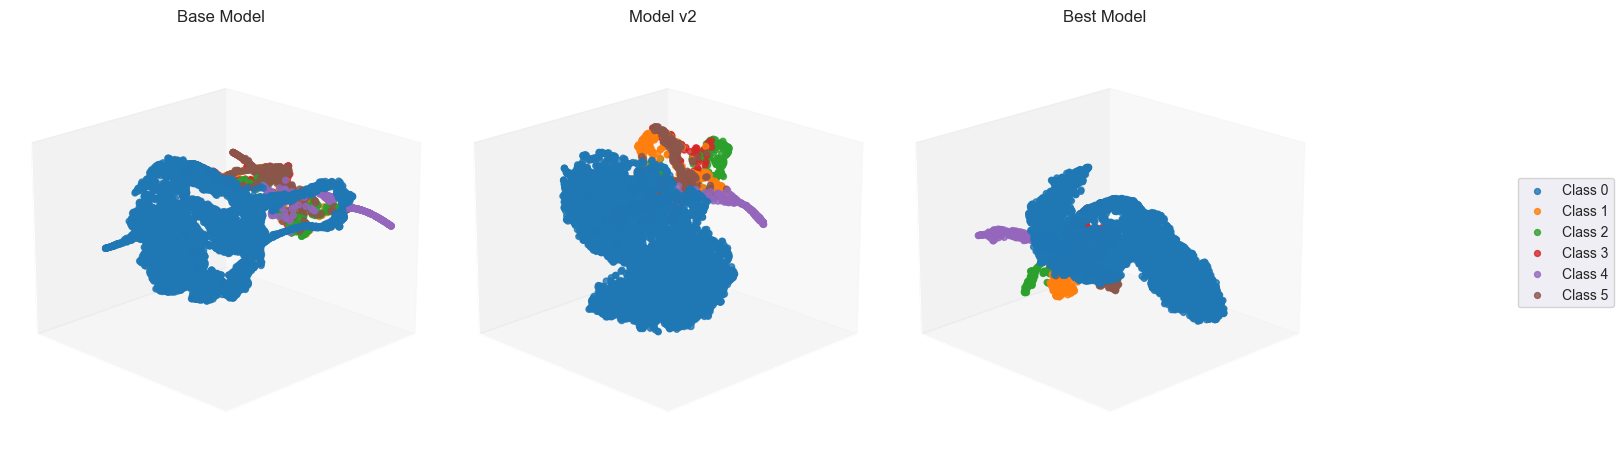


📊 Cluster Distance Metrics:
Base Model   → Intra-class = 23.906, Inter-class = 48.891, Ratio (inter/intra) = 2.045
Model v2     → Intra-class = 4.624, Inter-class = 8.828, Ratio (inter/intra) = 1.909
Best Model   → Intra-class = 4.895, Inter-class = 11.187, Ratio (inter/intra) = 2.285


In [10]:
import tensorflow as tf
import numpy as np
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

# -------------------------------
# Helper: Extract penultimate-layer features
# -------------------------------
def extract_features(model, X):
    # Find the last non-softmax dense layer
    target_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Dense) and layer.activation.__name__ != "softmax":
            target_layer = layer.name
            break
    if target_layer is None:
        raise ValueError("No non-softmax Dense layer found!")

    # Build feature extractor
    if isinstance(model, tf.keras.Sequential):
        extractor = tf.keras.Sequential(model.layers[:-1])
    else:
        extractor = tf.keras.Model(inputs=model.input, outputs=model.get_layer(target_layer).output)

    feats = extractor.predict(X, batch_size=128, verbose=0)
    return feats.reshape(feats.shape[0], -1)

# -------------------------------
# Load models
# -------------------------------
base_model = model
model_v2   = tf.keras.models.load_model(f"best_model_subject_{SUBJECT}_K50_m2_unbalanced.h5")
best_model = tf.keras.models.load_model(f"best_model_subject_{SUBJECT}_K64_good_unbalanced.h5")

models = {"Base Model": base_model, "Model v2": model_v2, "Best Model": best_model}

# -------------------------------
# Feature extraction
# -------------------------------
features_dict = {name: extract_features(m, X_test) for name, m in models.items()}
for name, f in features_dict.items():
    print(f"{name}: feature shape = {f.shape}")

# -------------------------------
# t-SNE (shared embedding space)
# -------------------------------
tsne = TSNE(n_components=3, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
all_feats = np.concatenate(list(features_dict.values()), axis=0)
all_embeds = tsne.fit_transform(all_feats)

split_points = np.cumsum([f.shape[0] for f in features_dict.values()])[:-1]
embeddings_split = np.split(all_embeds, split_points)

# -------------------------------
# Visualization: clean 3D subplot
# -------------------------------
fig = plt.figure(figsize=(18, 6))
for i, (name, emb) in enumerate(zip(features_dict.keys(), embeddings_split)):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    # transparent + clean aesthetics
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    # plot points per class
    classes = np.unique(y_test)
    for c in classes:
        idx = (y_test == c)
        ax.scatter(emb[idx, 0], emb[idx, 1], emb[idx, 2], label=f'Class {c}', s=18, alpha=0.8)

    ax.set_title(name, fontsize=12, pad=10)
    ax.view_init(elev=20, azim=45)

# Shared legend outside
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5))
plt.subplots_adjust(right=0.85, wspace=0.05)
plt.show()

# -------------------------------
# Quantitative: cluster compactness
# -------------------------------
def cluster_metrics(features, labels):
    centers = np.array([features[labels == c].mean(axis=0) for c in np.unique(labels)])
    intra_d = np.mean([pairwise_distances(features[labels == c], [centers[i]]).mean()
                       for i, c in enumerate(np.unique(labels))])
    inter_d = np.mean(pairwise_distances(centers))
    return intra_d, inter_d

print("\n📊 Cluster Distance Metrics:")
for name, feats in features_dict.items():
    intra, inter = cluster_metrics(feats, y_test)
    print(f"{name:12s} → Intra-class = {intra:.3f}, Inter-class = {inter:.3f}, Ratio (inter/intra) = {inter/intra:.3f}")

In [11]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
import numpy as np

def cluster_metrics(features, labels):
    """Compute intra/inter distances and silhouette score."""
    # Compute cluster centers
    centers = np.array([
        features[labels == c].mean(axis=0)
        for c in np.unique(labels)
    ])

    # Intra-class distance (compactness)
    intra_d = np.mean([
        pairwise_distances(features[labels == c], [centers[i]]).mean()
        for i, c in enumerate(np.unique(labels))
    ])

    # Inter-class distance (separation)
    inter_d = np.mean(pairwise_distances(centers))

    # Silhouette score (overall cluster quality)
    sil = silhouette_score(features, labels, metric='euclidean')

    return intra_d, inter_d, sil


# ------------------------------------------
# Compare multiple feature sets
# ------------------------------------------
print("\n📊 Cluster Distance & Silhouette Metrics:")
for name, feats in features_dict.items():
    intra, inter, sil = cluster_metrics(feats, y_test)
    print(f"{name:12s} → Intra = {intra:.3f}, Inter = {inter:.3f}, "
          f"Ratio = {inter/intra:.3f}, Silhouette = {sil:.3f}")


📊 Cluster Distance & Silhouette Metrics:
Base Model   → Intra = 23.906, Inter = 48.891, Ratio = 2.045, Silhouette = 0.515
Model v2     → Intra = 4.624, Inter = 8.828, Ratio = 1.909, Silhouette = 0.626
Best Model   → Intra = 4.895, Inter = 11.187, Ratio = 2.285, Silhouette = 0.520


In [34]:
from sklearn.manifold import TSNE

# ------------------------------------
# 1. Extract penultimate-layer features
# ------------------------------------
def extract_features(model, X):
    target_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Dense) and layer.activation.__name__ != "softmax":
            target_layer = layer.name
            break
    if target_layer is None:
        raise ValueError("No non-softmax Dense layer found!")

    if isinstance(model, tf.keras.Sequential):
        extractor = tf.keras.Sequential(model.layers[:-1])
    else:
        extractor = tf.keras.Model(inputs=model.input, outputs=model.get_layer(target_layer).output)
    feats = extractor.predict(X, batch_size=128, verbose=0)
    return feats.reshape(feats.shape[0], -1)

# ------------------------------------
# 2. Feature extraction (best model)
# ------------------------------------
#features_best = extract_features(base_model, X_test)
#features_best = extract_features(model_v2, X_test)
features_best = extract_features(best_model, X_test)
# ------------------------------------
# 3. t-SNE in 3D
# ------------------------------------
tsne = TSNE(n_components=3, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
features_3d = tsne.fit_transform(features_best)

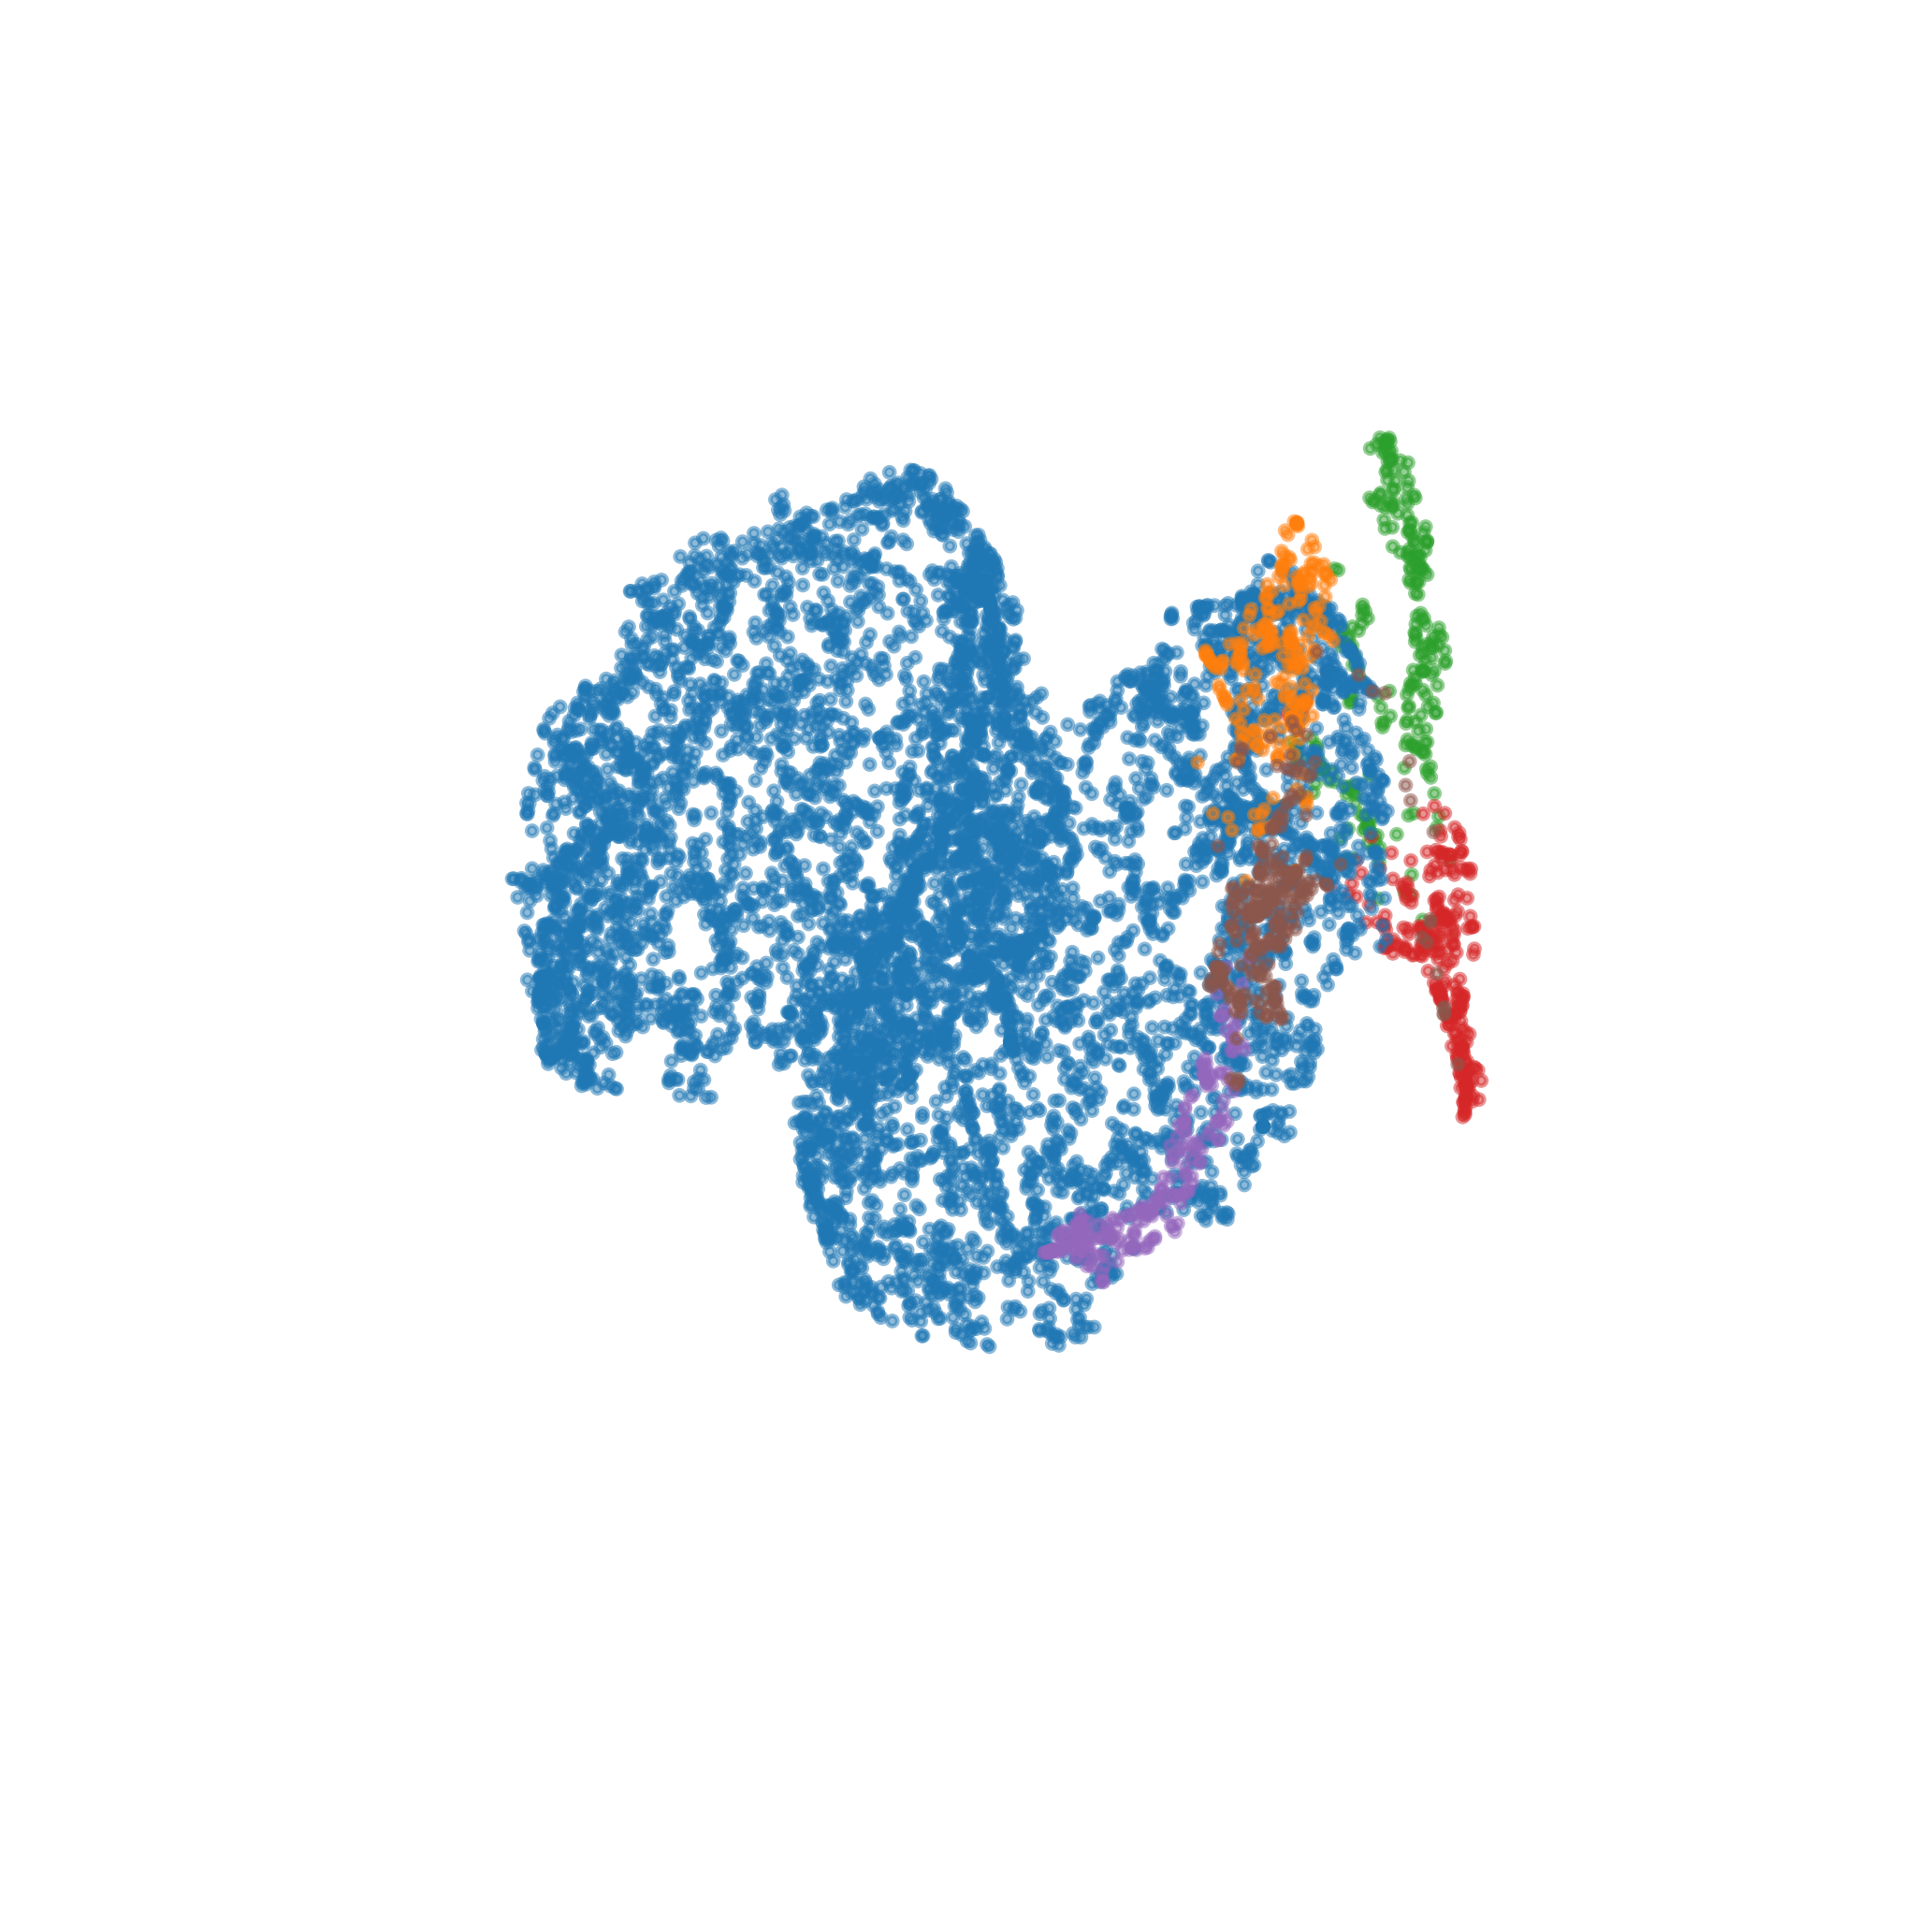

In [41]:
fig = plt.figure(figsize=(7, 6), dpi=350)
ax = fig.add_subplot(111, projection='3d')

classes = np.unique(y_test)
for c in classes:
    idx = (y_test == c)
    ax.scatter(features_3d[idx, 0], features_3d[idx, 1], features_3d[idx, 2], s=5, alpha=0.5, label=f"Class {c}")

# Hide all axes, grids, ticks, panes, and background
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
ax.grid(False)
ax.set_facecolor("none")
fig.patch.set_alpha(0.0)

# Hide 3D panes and box lines
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('none')
    axis.line.set_color((1, 1, 1, 0))

# Maintain equal scaling
ax.set_box_aspect([1, 1, 1])

# Adjust view angle
ax.view_init(elev=20, azim=90)  #18, 45

# Minimal legend outside plot
#leg = ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
#for lh in leg.legendHandles:
#    lh._sizes = [40]

plt.tight_layout()
plt.show()